In [49]:
import numpy as np
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import TimeSeriesSplit
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.metrics import mean_absolute_error, root_mean_squared_error

## Data Importing

In [50]:
file_path = "./data/raw/Energy_consumption.csv"


df = pd.read_csv(Path(file_path))
df.head(5)

,Timestamp,Temperature,Humidity,SquareFootage,Occupancy,HVACUsage,LightingUsage,RenewableEnergy,DayOfWeek,Holiday,EnergyConsumption
0,2022-01-01 00:00:00,25.139433,43.431581,1565.693999,5,On,Off,2.774699,Monday,No,75.364373
1,2022-01-01 01:00:00,27.731651,54.225919,1411.064918,1,On,On,21.831384,Saturday,No,83.401855
2,2022-01-01 02:00:00,28.704277,58.907658,1755.715009,2,Off,Off,6.764672,Sunday,No,78.270888
3,2022-01-01 03:00:00,20.080469,50.371637,1452.316318,1,Off,On,8.623447,Wednesday,No,56.519850
4,2022-01-01 04:00:00,23.097359,51.401421,1094.130359,9,On,Off,3.071969,Friday,No,70.811732


In [51]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Timestamp          1000 non-null   object 
 1   Temperature        1000 non-null   float64
 2   Humidity           1000 non-null   float64
 3   SquareFootage      1000 non-null   float64
 4   Occupancy          1000 non-null   int64  
 5   HVACUsage          1000 non-null   object 
 6   LightingUsage      1000 non-null   object 
 7   RenewableEnergy    1000 non-null   float64
 8   DayOfWeek          1000 non-null   object 
 9   Holiday            1000 non-null   object 
 10  EnergyConsumption  1000 non-null   float64
dtypes: float64(5), int64(1), object(5)
memory usage: 86.1+ KB


## Data Preprocessing

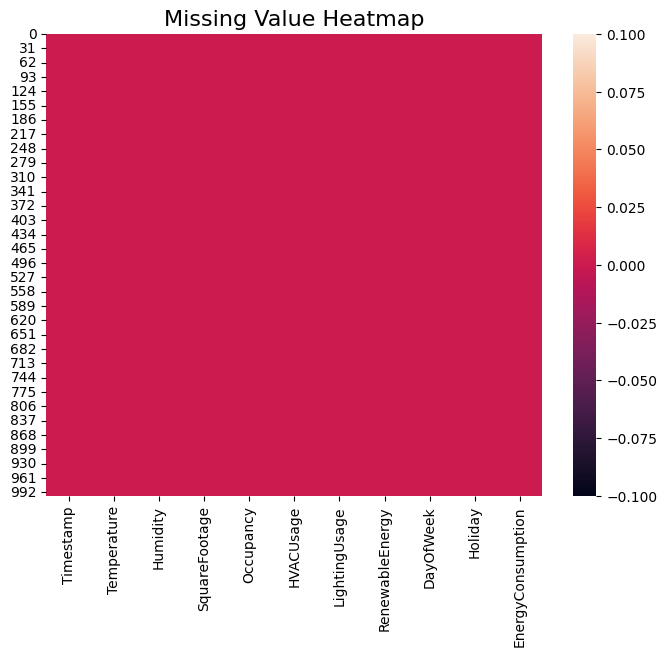

In [52]:
plt.figure(figsize=(8,6))
sns.heatmap(df.isna())
plt.title("Missing Value Heatmap", fontsize=16)
plt.show()

In [63]:
#Date time conversion
df['Timestamp'] = pd.to_datetime(df['Timestamp'])
#Time feature
df['hour'] = df['Timestamp'].dt.hour
df['month'] = df['Timestamp'].dt.month


## Data Exploratory

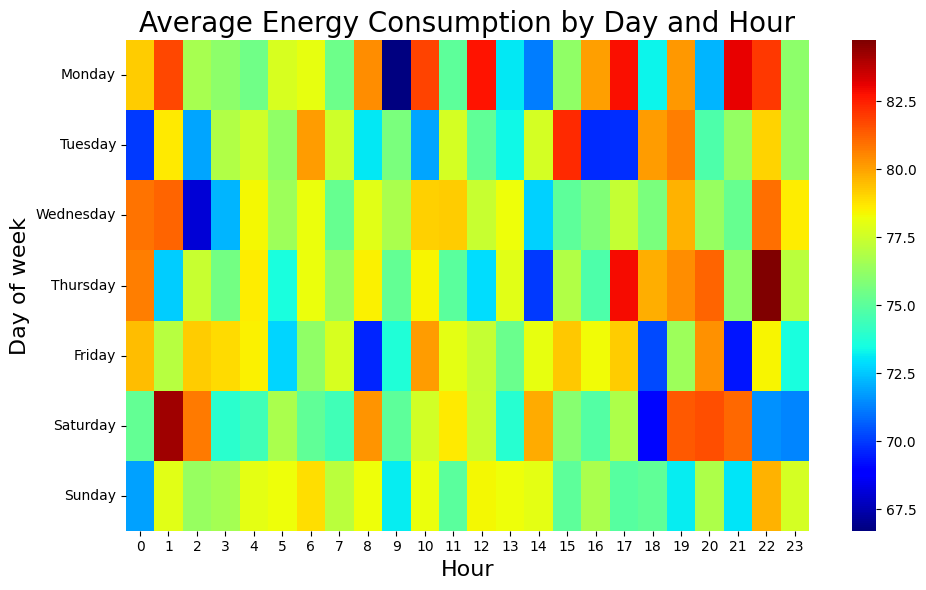

In [70]:
day_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]

heatmap = df.pivot_table(
    index='DayOfWeek',
    columns='hour',
    values='EnergyConsumption',
    aggfunc='mean'
).reindex(day_order)

plt.figure(figsize=(10, 6))
sns.heatmap(heatmap, cmap="jet")
plt.title("Average Energy Consumption by Day and Hour", fontsize=20)
plt.ylabel("Day of week", fontsize=16)
plt.xlabel("Hour", fontsize=16)
plt.tight_layout()
plt.show()

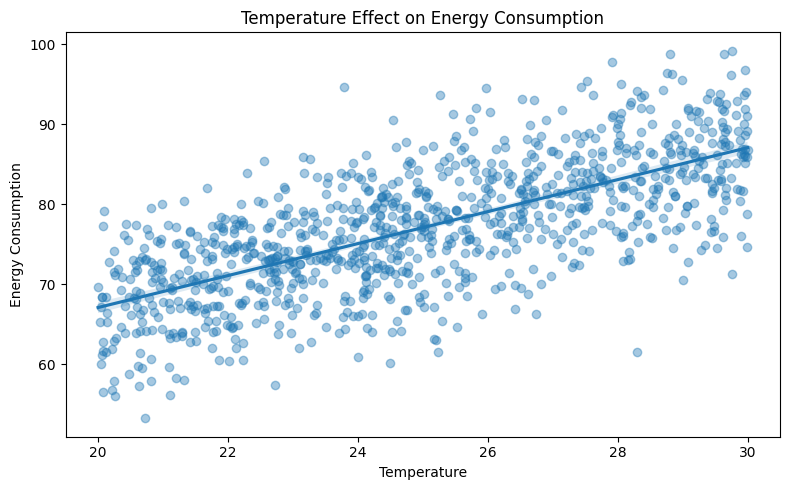

In [ ]:
plt.figure(figsize=(10, 6))
sns.regplot(data=df, x='Temperature', y)

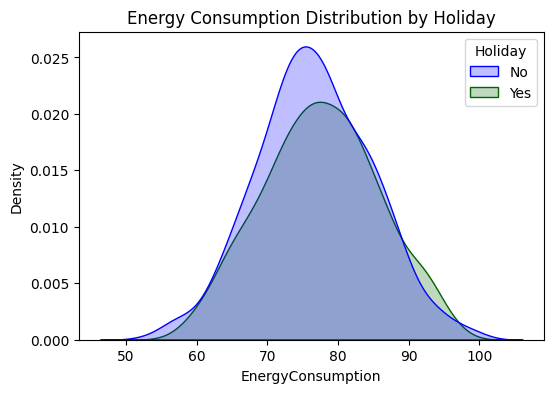

In [56]:
plt.figure(figsize=(6,4))

sns.kdeplot(
    data=df,
    x='EnergyConsumption',
    hue='Holiday',
    fill=True,
    palette=['blue', 'darkgreen']
)

plt.title("Energy Consumption Distribution by Holiday")
plt.show()

In [ ]:
data = df.copy()
data = data.sort_values("Timestamp")

#One-hot encoding
data = pd.get_dummies(data, columns=[
    "HVACUsage", "LightingUsage", 'DayOfWeek', 'Holiday'
], drop_first=True)

#Lag feature
data['lag_1'] = data['EnergyConsumption'].shift(1)
data['lag_2'] = data['EnergyConsumption'].shift(2)
data['lag_24'] = data['EnergyConsumption'].shift(24)

#Rolling feature
data['rolling_mean'] = data['EnergyConsumption'].rolling(24).mean()

data = data.dropna()

data.head()

## Training

In [57]:
X = data.drop(['EnergyConsumption', 'Timestamp'], axis=1)
y = data['EnergyConsumption']

tscv = TimeSeriesSplit(n_splits=5)

models = {
    "Linear": LinearRegression(),
    "Ridge": Ridge(),
    "Lasso": Lasso(),
    "DecisionTree": DecisionTreeRegressor(max_depth=5),
    "RandomForest": RandomForestRegressor(n_estimators=100),
    "GradientBoosting": GradientBoostingRegressor(),
    "SVR": SVR()
}

X.dtypes, y.dtypes

(Temperature            float64
 Humidity               float64
 SquareFootage          float64
 Occupancy                int64
 RenewableEnergy        float64
 hour                     int32
 month                    int32
 HVACUsage_On              bool
 LightingUsage_On          bool
 DayOfWeek_Monday          bool
 DayOfWeek_Saturday        bool
 DayOfWeek_Sunday          bool
 DayOfWeek_Thursday        bool
 DayOfWeek_Tuesday         bool
 DayOfWeek_Wednesday       bool
 Holiday_Yes               bool
 lag_1                  float64
 lag_2                  float64
 lag_24                 float64
 rolling_mean           float64
 dtype: object,
 dtype('float64'))

In [58]:
results = []
for name, model in models.items():
    mae_list = []
    rmse_list = []
    for train_idx, test_idx in tscv.split(X):
        X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
        y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

        mae = mean_absolute_error(y_test, y_pred)
        rmse = root_mean_squared_error(y_test, y_pred)

        mae_list.append(mae)
        rmse_list.append(rmse)

    results.append({
        "Model": name,
        "MAE": np.mean(np.array(mae_list)),
        "RMSE": np.mean(np.array(rmse_list))
    })

results_df = pd.DataFrame(results).sort_values("RMSE", ascending=True)
results_df


,Model,MAE,RMSE
1,Ridge,4.138755,5.142885
0,Linear,4.141637,5.145905
5,GradientBoosting,4.369121,5.461118
4,RandomForest,4.435789,5.509087
2,Lasso,4.456034,5.534665
3,DecisionTree,5.066015,6.375958
6,SVR,6.602839,8.154018
